In [38]:
from geotab_processor import GeotabProcessor

processor = GeotabProcessor('config.yml')

Trip date: 2026-03-12


In [39]:
# Process and preview vars (motor status report)
vars_df = processor.process_vars()
vars_df.head(15)

vars: 410 rows


,datetime,Voltage,Current,Power,SoC,Procedencia
0,2026-03-12 08:43:23.434,380.500000,2.998686,1141.0,81.220000,AA
1,2026-03-12 08:45:03.914,380.425501,-34.687475,-13196.0,81.195436,AA
2,2026-03-12 08:45:11.941,380.351003,49.690943,18900.0,81.170872,AA
3,2026-03-12 08:45:22.000,380.276504,-42.024684,-15981.0,81.146309,AA
4,2026-03-12 08:45:30.043,380.202006,39.926144,15180.0,81.121745,AA
5,2026-03-12 08:51:05.578,380.127507,64.959782,24693.0,81.097181,AA
6,2026-03-12 08:51:10.590,380.053009,-34.539919,-13127.0,81.072617,AA
7,2026-03-12 08:51:52.750,379.978510,-3.494934,-1328.0,81.048054,AA
8,2026-03-12 08:52:00.801,379.904011,123.878660,47062.0,81.023490,AA
9,2026-03-12 08:52:07.820,379.829513,-0.992551,-377.0,80.998926,AA


In [40]:
# Process and preview GPS (data log)
gps_df = processor.process_gps()
gps_df.head(15)

gps: 1445 rows


,datetime,latitude,longitude
0,2026-03-12 08:43:18.372,9.93720,-84.04373
1,2026-03-12 08:43:18.395,9.93720,-84.04373
2,2026-03-12 08:43:23.000,9.93720,-84.04373
3,2026-03-12 08:43:37.000,9.93713,-84.04377
4,2026-03-12 08:44:23.333,9.93713,-84.04377
5,2026-03-12 08:44:35.000,9.93713,-84.04377
6,2026-03-12 08:44:36.000,9.93713,-84.04374
7,2026-03-12 08:44:40.000,9.93706,-84.04369
8,2026-03-12 08:44:42.000,9.93704,-84.04367
9,2026-03-12 08:44:46.000,9.93710,-84.04360


In [41]:
# Merge vars into GPS → route_vars
route_vars_df = processor.merge_route_vars()
route_vars_df.head(15)

route_vars: 1445 rows


,datetime,latitude,longitude,Voltage,Current,Power,SoC,Procedencia
0,2026-03-12 08:43:18.372,9.93720,-84.04373,380.500000,2.998686,1141.0,81.220000,AA
1,2026-03-12 08:43:18.395,9.93720,-84.04373,380.500000,2.998686,1141.0,81.220000,AA
2,2026-03-12 08:43:23.000,9.93720,-84.04373,380.500000,2.998686,1141.0,81.220000,AA
3,2026-03-12 08:43:37.000,9.93713,-84.04377,380.500000,2.998686,1141.0,81.220000,AA
4,2026-03-12 08:44:23.333,9.93713,-84.04377,380.462751,-15.844394,-6027.5,81.207718,AA
5,2026-03-12 08:44:35.000,9.93713,-84.04377,380.425501,-34.687475,-13196.0,81.195436,AA
6,2026-03-12 08:44:36.000,9.93713,-84.04374,380.425501,-34.687475,-13196.0,81.195436,AA
7,2026-03-12 08:44:40.000,9.93706,-84.04369,380.425501,-34.687475,-13196.0,81.195436,AA
8,2026-03-12 08:44:42.000,9.93704,-84.04367,380.425501,-34.687475,-13196.0,81.195436,AA
9,2026-03-12 08:44:46.000,9.93710,-84.04360,380.425501,-34.687475,-13196.0,81.195436,AA


In [42]:
# Save all outputs to CSV
processor.save()

Saved vars → processed_data\2026-03-12\vars.csv  (410 rows)
Saved gps  → processed_data\2026-03-12\gps.csv  (1445 rows)
Saved route_vars → processed_data\2026-03-12\route_vars.csv  (1445 rows)


In [43]:
# Densify route_vars (interpolate GPS points to fill gaps)
route_vars_df = processor.densify_gps()
print(f"Shape: {route_vars_df.shape}")

# Save densified route_vars to CSV
processor.save()

route_vars_df.head(15)

densify: 1445 → 18640 points (max gap 5m)
Shape: (18640, 8)
Saved vars → processed_data\2026-03-12\vars.csv  (410 rows)
Saved gps  → processed_data\2026-03-12\gps.csv  (1445 rows)
Saved route_vars → processed_data\2026-03-12\route_vars.csv  (18640 rows)


,datetime,latitude,longitude,Voltage,Current,Power,SoC,Procedencia
0,2026-03-12 08:43:18.372000000,9.937200,-84.043730,380.500000,2.998686,1141.0,81.220000,AA
1,2026-03-12 08:43:18.395000000,9.937200,-84.043730,380.500000,2.998686,1141.0,81.220000,AA
2,2026-03-12 08:43:23.000000000,9.937200,-84.043730,380.500000,2.998686,1141.0,81.220000,AA
3,2026-03-12 08:43:30.000000000,9.937165,-84.043750,380.500000,2.998686,1141.0,81.220000,AA
4,2026-03-12 08:43:37.000000000,9.937130,-84.043770,380.500000,2.998686,1141.0,81.220000,AA
5,2026-03-12 08:44:23.333000000,9.937130,-84.043770,380.462751,-15.844394,-6027.5,81.207718,AA
6,2026-03-12 08:44:35.000000000,9.937130,-84.043770,380.425501,-34.687475,-13196.0,81.195436,AA
7,2026-03-12 08:44:36.000000000,9.937130,-84.043740,380.425501,-34.687475,-13196.0,81.195436,AA
8,2026-03-12 08:44:38.000000000,9.937095,-84.043715,380.425501,-34.687475,-13196.0,81.195436,AA
9,2026-03-12 08:44:40.000000000,9.937060,-84.043690,380.425501,-34.687475,-13196.0,81.195436,AA


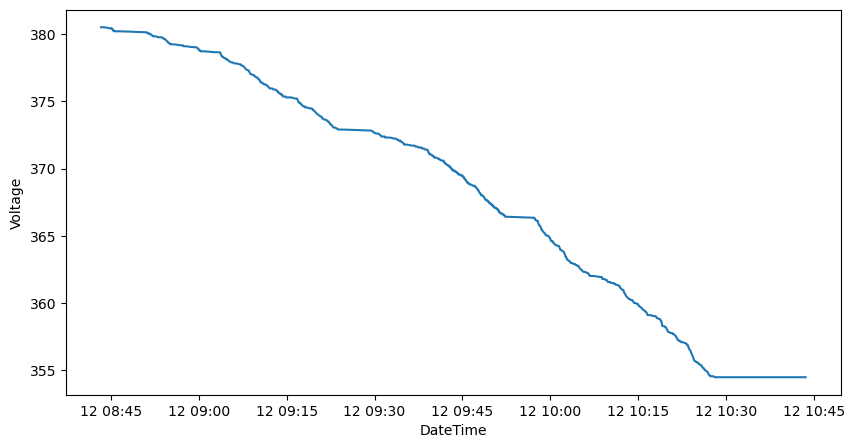

In [44]:
#plot SoC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(route_vars_df['datetime'], route_vars_df['Voltage'])
plt.xlabel('DateTime')
plt.ylabel('Voltage')
plt.show()

In [46]:
# One-time adjustment: reduce SoC by 5 percentage points at every point
if 'SoC' not in route_vars_df.columns:
    raise KeyError("'SoC' column not found in route_vars_df")

route_vars_df['SoC'] = (route_vars_df['SoC'] - 5).clip(lower=0)
route_vars_df[['datetime', 'SoC']].head(15)

,datetime,SoC
0,2026-03-12 08:43:18.372000000,76.220000
1,2026-03-12 08:43:18.395000000,76.220000
2,2026-03-12 08:43:23.000000000,76.220000
3,2026-03-12 08:43:30.000000000,76.220000
4,2026-03-12 08:43:37.000000000,76.220000
5,2026-03-12 08:44:23.333000000,76.207718
6,2026-03-12 08:44:35.000000000,76.195436
7,2026-03-12 08:44:36.000000000,76.195436
8,2026-03-12 08:44:38.000000000,76.195436
9,2026-03-12 08:44:40.000000000,76.195436


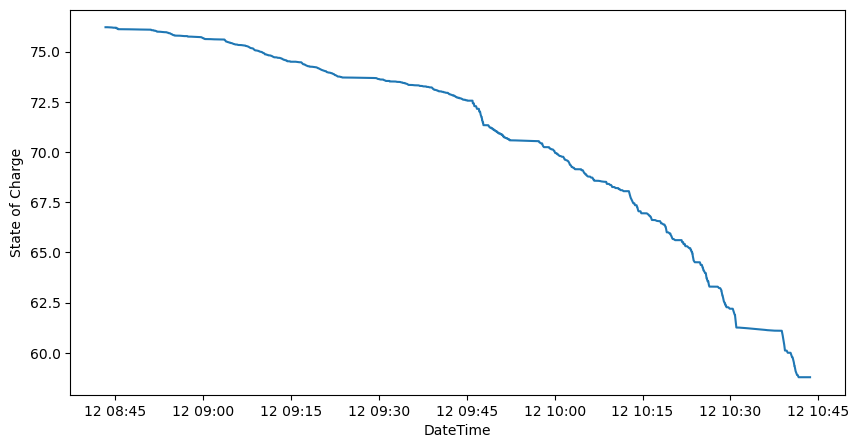

In [49]:
#plot SoC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(route_vars_df['datetime'], route_vars_df['SoC'])
plt.xlabel('DateTime')
plt.ylabel('State of Charge')
plt.show()

In [50]:
processor.save()

route_vars_df.head(15)

Saved vars → processed_data\2026-03-12\vars.csv  (410 rows)
Saved gps  → processed_data\2026-03-12\gps.csv  (1445 rows)
Saved route_vars → processed_data\2026-03-12\route_vars.csv  (18640 rows)


,datetime,latitude,longitude,Voltage,Current,Power,SoC,Procedencia
0,2026-03-12 08:43:18.372000000,9.937200,-84.043730,380.500000,2.998686,1141.0,76.220000,AA
1,2026-03-12 08:43:18.395000000,9.937200,-84.043730,380.500000,2.998686,1141.0,76.220000,AA
2,2026-03-12 08:43:23.000000000,9.937200,-84.043730,380.500000,2.998686,1141.0,76.220000,AA
3,2026-03-12 08:43:30.000000000,9.937165,-84.043750,380.500000,2.998686,1141.0,76.220000,AA
4,2026-03-12 08:43:37.000000000,9.937130,-84.043770,380.500000,2.998686,1141.0,76.220000,AA
5,2026-03-12 08:44:23.333000000,9.937130,-84.043770,380.462751,-15.844394,-6027.5,76.207718,AA
6,2026-03-12 08:44:35.000000000,9.937130,-84.043770,380.425501,-34.687475,-13196.0,76.195436,AA
7,2026-03-12 08:44:36.000000000,9.937130,-84.043740,380.425501,-34.687475,-13196.0,76.195436,AA
8,2026-03-12 08:44:38.000000000,9.937095,-84.043715,380.425501,-34.687475,-13196.0,76.195436,AA
9,2026-03-12 08:44:40.000000000,9.937060,-84.043690,380.425501,-34.687475,-13196.0,76.195436,AA


In [51]:
from GetFeatures import GetFeatures

feat = GetFeatures('config.yml', trip_date=processor.trip_date)
features_df = feat.run()
features_df.head(15)

Loaded 18640 points from processed_data\2026-03-12\route_vars.csv
  Total distance: 89.43 km
  Segments: 870 (target 100m)
  Weather fetched (5 location(s))
  Road features extracted
  Elevation fetched
  Slope computed
  Aggregated into 870 segments
Saved features → processed_data\2026-03-12\features.csv


,segment_id,Hour,Trip_distance,Delta_d,Hum,OAT[DegC]_API,precipMM,Slope,primary,residential,secondary,crossing,tertiary,give_way,Voltage,Current,Power,SoC
0,0,8,104.303908,104.303908,53.0,24.0,0.0,0.000000,0,1,0,0,0,0,380.439630,-27.540099,-10476.913793,76.200095
1,1,8,207.093869,102.789962,53.0,24.0,0.0,0.000000,0,1,0,0,0,0,380.363897,4.609171,1752.750000,76.175124
2,2,8,308.024330,100.930460,53.0,24.0,0.0,0.000000,0,1,0,0,0,0,380.237765,0.589746,222.720000,76.133536
3,3,8,412.230032,104.205703,53.0,24.0,0.0,0.000000,0,1,0,0,0,0,380.202006,39.926144,15180.000000,76.121745
4,4,8,512.813821,100.583789,53.0,24.0,0.0,0.000000,0,1,0,0,0,0,380.201939,39.948495,15188.493750,76.121723
5,5,8,612.941827,100.128006,53.0,24.0,0.0,-6.834108,0,1,0,0,0,0,380.196918,41.635617,15829.614583,76.120068
6,6,8,714.932327,101.990501,53.0,24.0,0.0,0.000000,0,1,0,0,0,0,380.189752,44.043893,16744.780398,76.117705
7,7,8,819.425045,104.492717,53.0,24.0,0.0,0.000000,0,0,0,0,0,0,380.187916,44.660590,16979.130682,76.117099
8,8,8,921.418344,101.993299,53.0,24.0,0.0,-2.806554,0,0,0,0,0,0,380.185590,45.442461,17276.248512,76.116332
9,9,8,1023.002196,101.583852,53.0,24.0,0.0,-1.691582,0,0,0,0,0,0,380.184204,45.908058,17453.179167,76.115875


In [ ]:
# from geotab_processor import GeotabProcessor

# processor = GeotabProcessor('config.yml')
# from SelectRoutes import SelectRoutes

# router = SelectRoutes('config.yml', trip_date=processor.trip_date)

# # Define origin, destination, and optional waypoints (lat, lon)
# origin = (9.938431618596065, -84.04242771006302)
# destination = (9.923002036510496, -84.71348341082084)
# waypoints = [
#     (9.946408312880324, -84.1075270242855),
#     (9.998852155871559, -84.20965794599373),
#     (9.992262390787275, -84.32110029105247),
#     (9.986162599612205, -84.33666694801252),
#     (9.960107878275323, -84.35899648875584),
#     (9.94379395064879, -84.37234399566964),
#     (9.942631291491299, -84.3989518633456),
#     (9.906426084502195, -84.52176653130655),
#     (9.890576370313543, -84.56242082436405)

# ]

# route_df, travel = router.run(origin, destination, waypoints)
# print(travel)
# route_df.head(15)

In [ ]:
# from GetFeatures import GetFeatures

# feat_route = GetFeatures('config.yml', trip_date='2026-03-06', input_file='route_coords.csv')
# features_route_df = feat_route.run()
# features_route_df.head(15)

In [ ]:
# # resta 5% SoC a ruta plana 
# import pandas as pd
# rutaplana = pd.read_csv('ruta_plana.csv')
# rutaplana['SoC'] = (rutaplana['SoC'] - 5).clip(lower=0)
# rutaplana.to_csv('ruta_plana_1.csv', index=False)